In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

from src.file_path import list_files_in_folder, filter_cvm_files
from src.metadata_utils import extract_read_CVM_dataframes, get_capacitance_near_target_bias
from src.metadata_utils import extract_first_timestamp, compute_elapsed_time_seconds, metadata_extraction
from src.metadata_utils import extract_index, extract_CVM_Average
from src.plot import plot_memCVM_retention_vs_time, plot_memCVM_retention_overview, plot_memCVM_average_vs_time
from src.export import write_csv_with_metadata

# ──────────────────────────────────────────────────────────────────────────────
#   This code is used to plot the data from the FE tester for the CV                       
# ──────────────────────────────────────────────────────────────────────────────

%config InlineBackend.figure_format = 'retina' # For high resolution figures in Jupyter Notebook
#%matplotlib widget

In [2]:
# ──────────────────────────────────────────────────────────────────────────────
#   Path                       
# ──────────────────────────────────────────────────────────────────────────────

folder_path = r"B:\Panda\FETester\Anwesha\Retention"
output_path = r"B:\Panda\FETester\Anwesha\Retention"

output_path_csv = os.path.join(output_path, "csv")
output_path_plot = os.path.join(output_path, "plot")

In [3]:
# ──────────────────────────────────────────────────────────────────────────────
#   Extraction of dataframes from the source folder                       
# ──────────────────────────────────────────────────────────────────────────────

CVM_reading_files = filter_cvm_files(list_files_in_folder(folder_path))
CVM_reading_files = sorted(CVM_reading_files, key =extract_index) #Sort the file par ordre croissant

DF_CVM, Timestamps = extract_read_CVM_dataframes(CVM_reading_files)
metadata = metadata_extraction(CVM_file=CVM_reading_files[0])

CVM_average = extract_CVM_Average(CVM_reading_files)

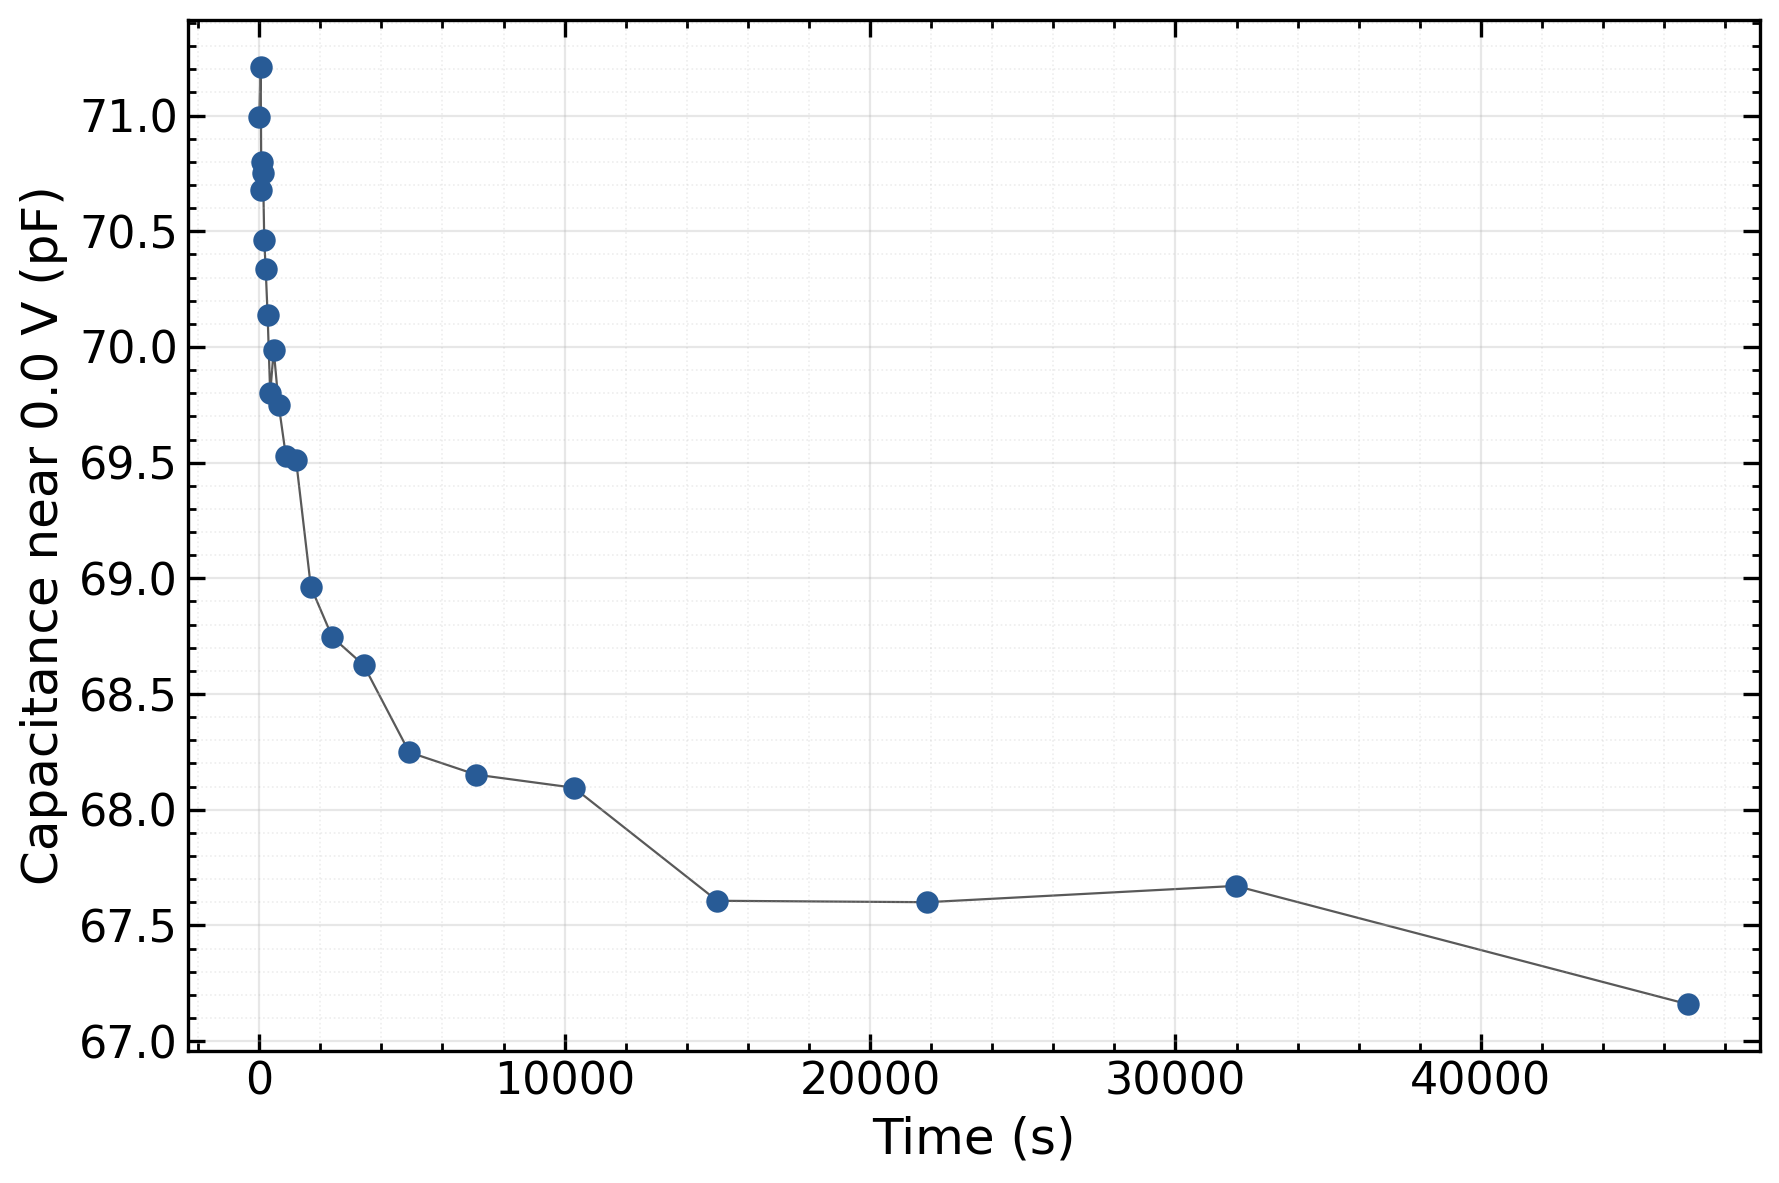

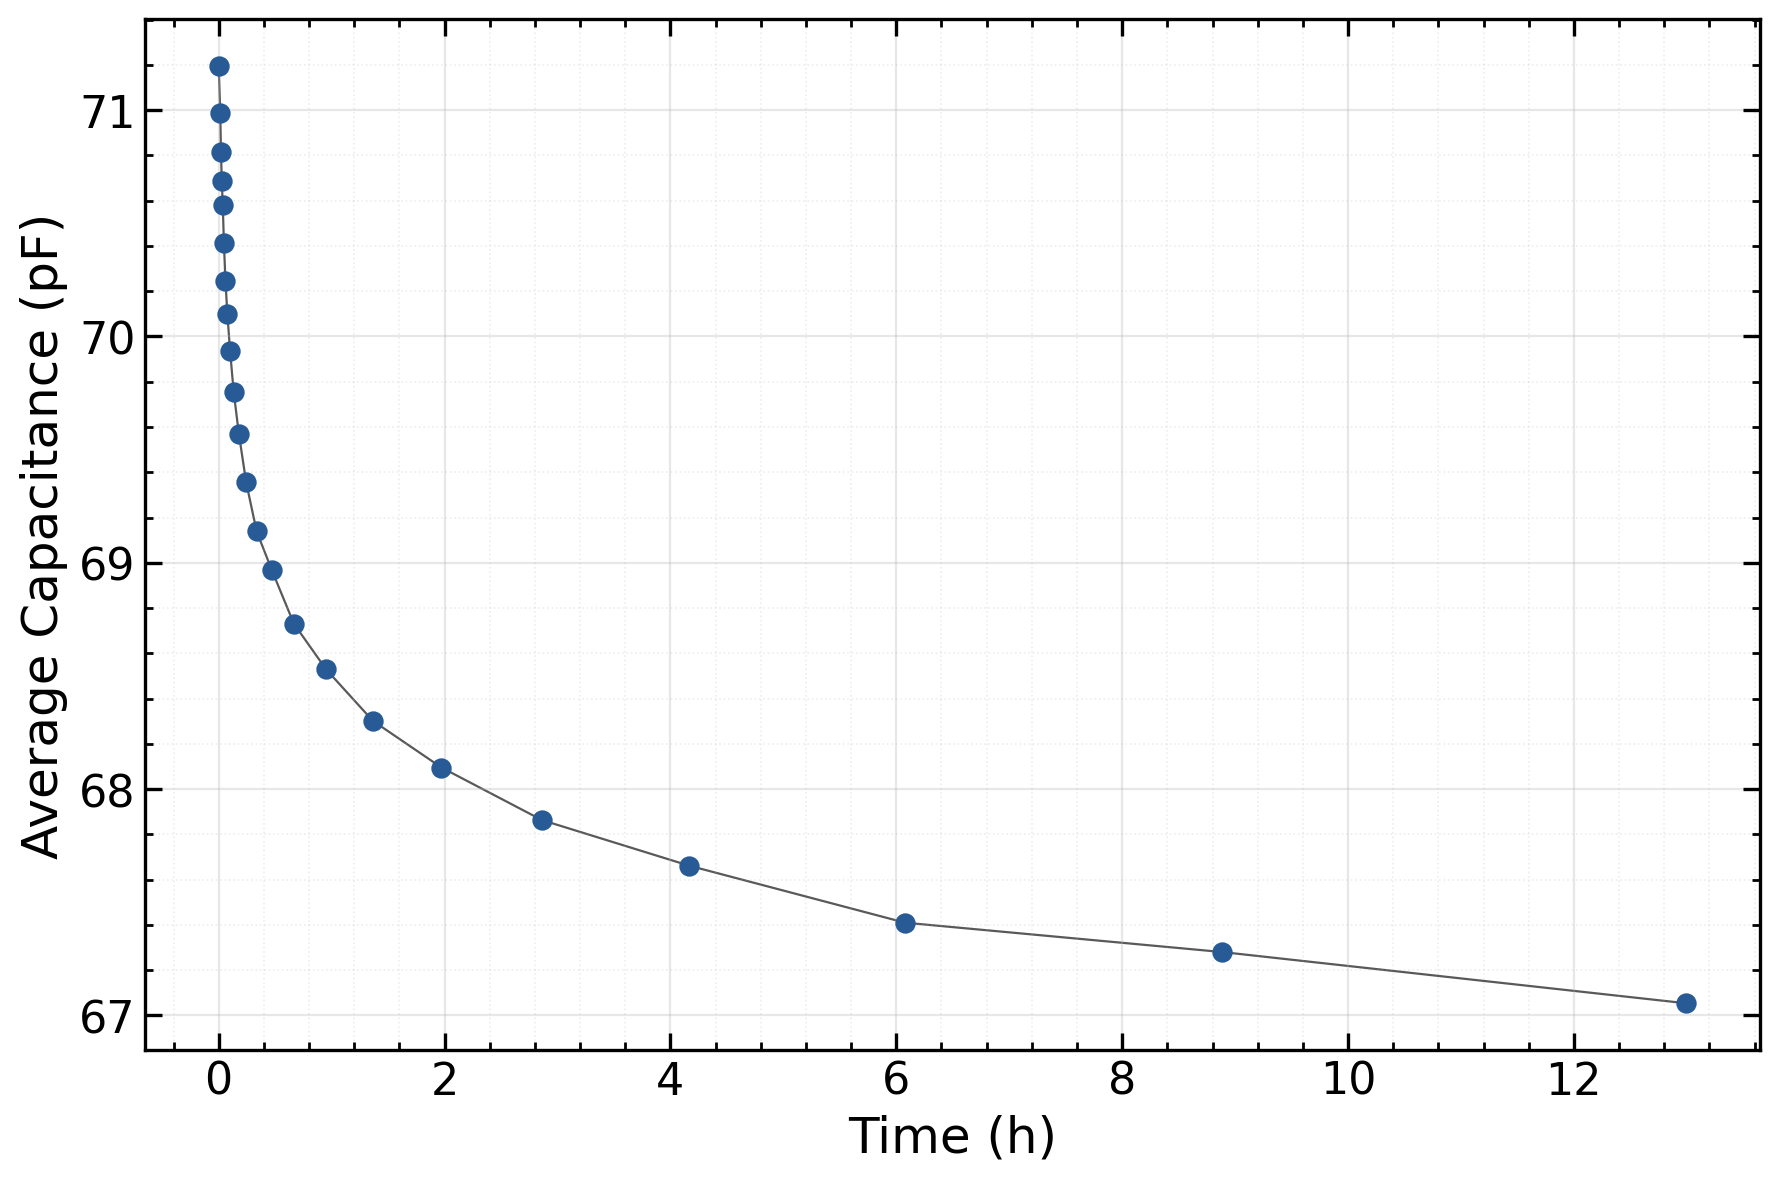

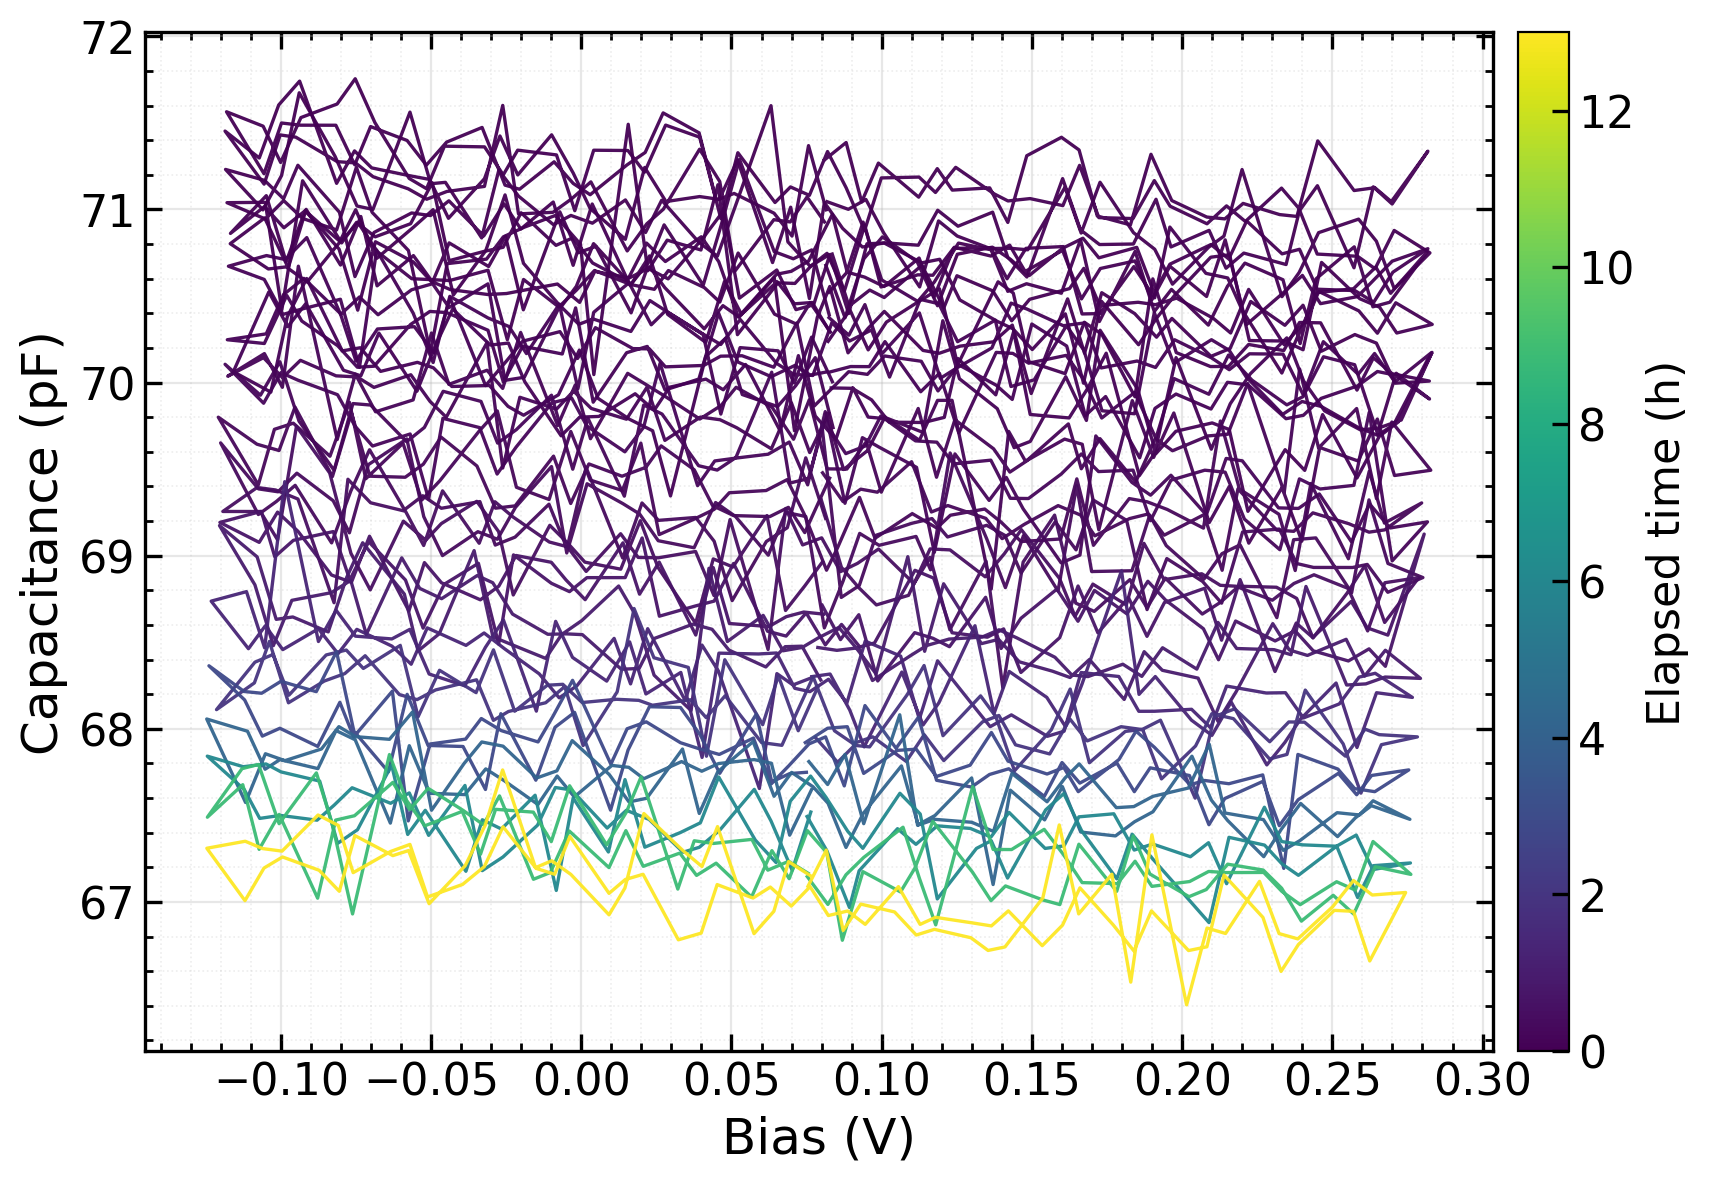

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
#   Plot                      
# ──────────────────────────────────────────────────────────────────────────────

READING_VOLTAGE = 0.0   

DF_RETENTION = plot_memCVM_retention_vs_time(
    DF_CVM=DF_CVM,
    Timestamps=Timestamps,
    Output_dir=output_path_plot,
    reading_voltage=READING_VOLTAGE,
    time_unit="s",                      # "s", "h", "days"
    marker_size=50,
    title=None
)

plot_memCVM_average_vs_time(
    DF_Cav=CVM_average,
    Timestamps=Timestamps,
    Output_dir=output_path_plot,
    time_unit="h",                 # "s", "h", "days"
)

plot_memCVM_retention_overview(
    DF_CVM=DF_CVM,
    Timestamps=Timestamps,
    Output_dir=output_path_plot,
    time_unit="h",                 # "s", "h", "days"
    filename_suffix="2026-01-19_NASA_XXX_retention",
)

write_csv_with_metadata(
Output_path=output_path_csv,
df_metadata=metadata,
df_data=DF_RETENTION,
Reading_voltage=READING_VOLTAGE  
)